In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/home/vince/ENSTA/4A/projet/anomalib/results/mvtec_results_22_02_2026.csv")
df["model_x_category"] = df["model"] + "_" + df["category"]

In [27]:
df["ranking_model_per_cat_img_AUROC"] = df[["category","model","image_AUROC"]].groupby("category")["image_AUROC"].rank(ascending=False, method="min").astype(int)
df["ranking_model_per_cat_pixel_AUROC"] = df[["category","model","pixel_AUROC"]].groupby("category")["pixel_AUROC"].rank(ascending=False, method="min").astype(int)

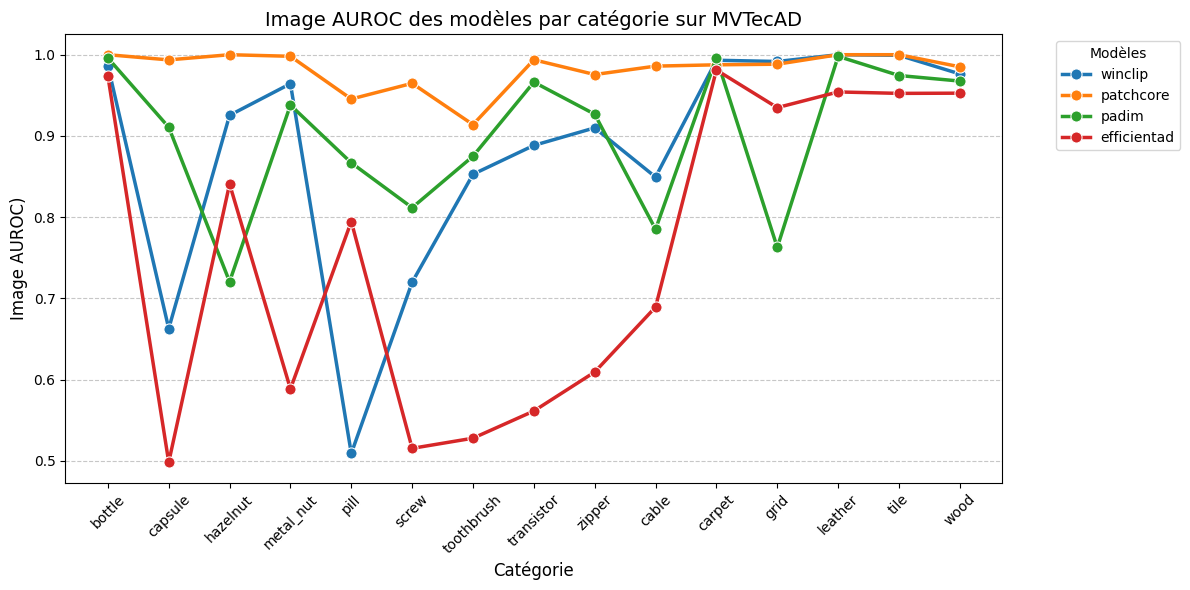

In [30]:
plt.figure(figsize=(12, 6))

# On utilise lineplot : x = catégories, y = rang, hue = modèle pour avoir une ligne par modèle
sns.lineplot(data=df, x="category", y="image_AUROC", hue="model", 
             marker="o", linewidth=2.5, markersize=8)

# 5. Esthétique
plt.title("Image AUROC des modèles par catégorie sur MVTecAD", fontsize=14)
plt.xlabel("Catégorie", fontsize=12)
plt.ylabel("Image AUROC)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Modèles", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

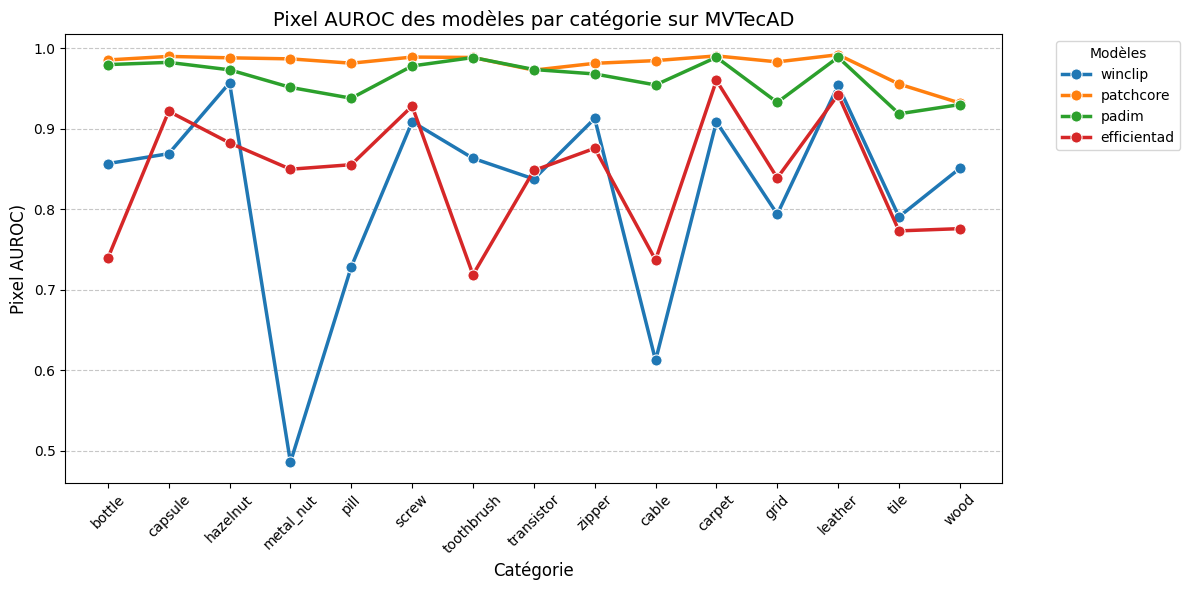

In [ ]:
plt.figure(figsize=(12, 6))

# On utilise lineplot : x = catégories, y = rang, hue = modèle pour avoir une ligne par modèle
sns.lineplot(data=df, x="category", y="pixel_AUROC", hue="model", 
             marker="o", linewidth=2.5, markersize=8)

# 5. Esthétique
plt.title("Pixel AUROC des modèles par catégorie sur MVTecAD", fontsize=14)
plt.xlabel("Catégorie", fontsize=12)
plt.ylabel("Pixel AUROC)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Modèles", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Axes: xlabel='category', ylabel='model'>

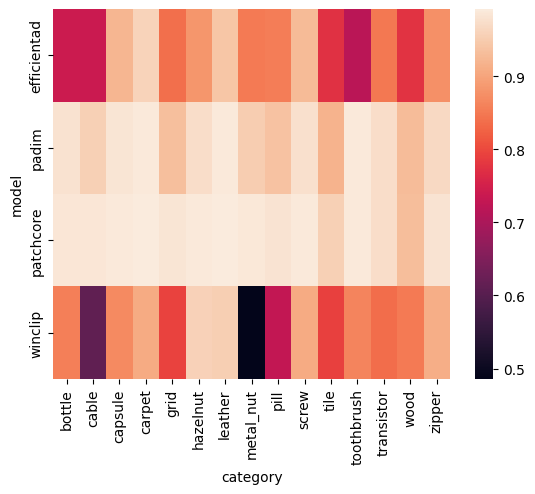

In [ ]:
df_heatmap = df.copy()
df_heatmap = df_heatmap[["pixel_AUROC","model","category"]]
df_heatmap = df_heatmap.pivot(columns="category", index="model", values="pixel_AUROC")
sns.heatmap(df_heatmap)